# 01 — Data Loading and Exploration

**Dataset:** NIR Corn Spectra — 80 samples, 700 wavelength columns, 4 label columns (Moisture, Starch, Oil, Protein).

**Goal:** Load the raw dataset, look at its structure, check the label distributions, and visualize the raw spectra.

> No preprocessing, data splitting, or file saving is done in this notebook.

## 1. Imports and Setup

Import the four libraries we need: `pandas` for handling the data table, `numpy` for math, and `matplotlib` + `seaborn` for making charts. We also set a clean plot style here.

In [8]:
import sys
sys.path.append('..')
from src.data_loader import load_raw_data
from src.visualizer import plot_spectra, plot_spectra_by_label, plot_protein_distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set a clean plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

Load the CSV file into a pandas DataFrame, check its shape, and look at the first few rows. Then separate the 700 spectral columns into `X` and the 4 label columns into `labels_df`.

In [9]:
X, labels_df, sample_ids = load_raw_data('../data/raw/corn_mp5_regression_data.csv')

Dataset loaded: 80 samples, 705 columns
X shape       : (80, 700)  (samples x wavelength channels)
labels_df shape: (80, 4)  (samples x labels)


In [10]:
print(f"X shape       : {X.shape}  (samples x wavelength channels)")
print(f"labels_df shape: {labels_df.shape}  (samples x labels)")
print(f"\nLabel columns : {list(labels_df.columns)}")

X shape       : (80, 700)  (samples x wavelength channels)
labels_df shape: (80, 4)  (samples x labels)

Label columns : ['Moisture', 'Starch', 'Oil', 'Protein']


## 3. Descriptive Statistics

Use `.describe()` to get a quick summary of all four label columns. We also compute the **median protein value** — this will later be used as the threshold to define *High Protein* vs *Low Protein* classes.

In [11]:
print("Descriptive statistics for all four label columns:\n")
display(labels_df.describe().round(4))

median_protein = labels_df['Protein'].median()
print(f"\nMedian Protein value: {median_protein:.4f} %")

Descriptive statistics for all four label columns:



,Moisture,Starch,Oil,Protein
count,80.0000,80.0000,80.0000,80.0000
mean,10.2335,3.4984,8.6683,64.6956
std,0.3804,0.1770,0.4986,0.8207
min,9.3770,3.0880,7.6540,62.8260
25%,9.9560,3.4062,8.2875,64.2648
50%,10.2825,3.4965,8.5615,64.8220
75%,10.4655,3.6420,9.0188,65.3455
max,10.9930,3.8320,9.7110,66.4720



Median Protein value: 64.8220 %


## 4. Protein Distribution Plot

A histogram with a kernel density estimate (KDE) shows how protein values are spread across all 80 samples. The dashed vertical line marks the median — the value we will use as the classification threshold.

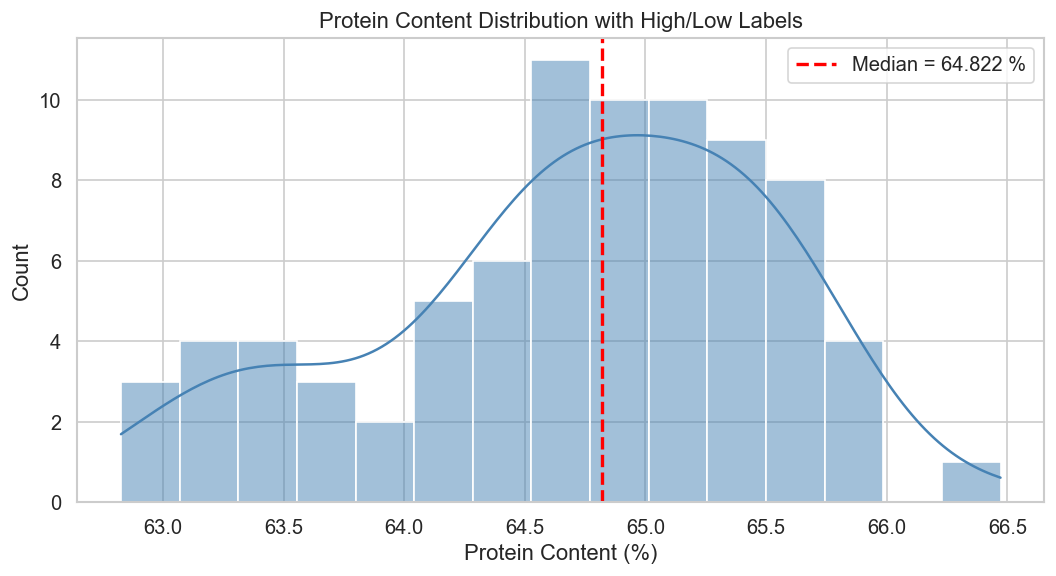

In [12]:
plot_protein_distribution(labels_df['Protein'], median_protein)

## 5. Raw NIR Spectra Plot

Plot all 80 spectra on one figure. The x-axis is the actual wavelength in nm (1100–2498 nm), and the y-axis is absorbance. Using a low alpha makes overlapping lines easier to see.

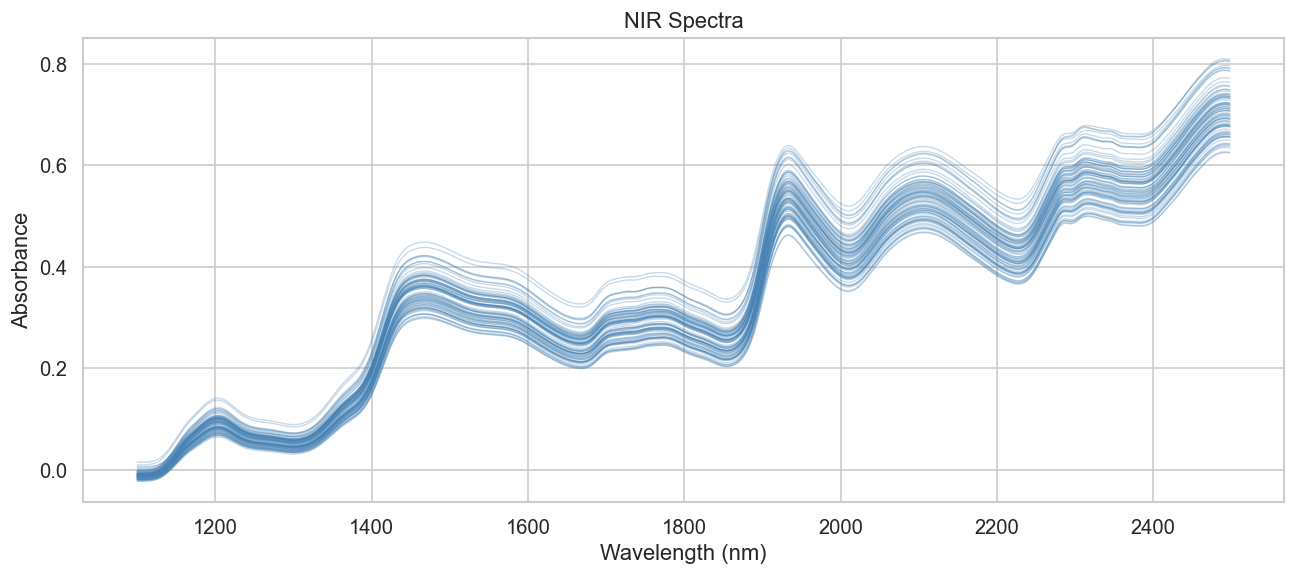

In [13]:
plot_spectra(X)

## 6. Spectra Colored by Protein Group

Re-plot the spectra and color each one based on whether the sample's protein value is above or below the median:
- **Red** = High Protein (above median)
- **Blue** = Low Protein (at or below median)

> This is for visual exploration only — no labels are officially assigned here.

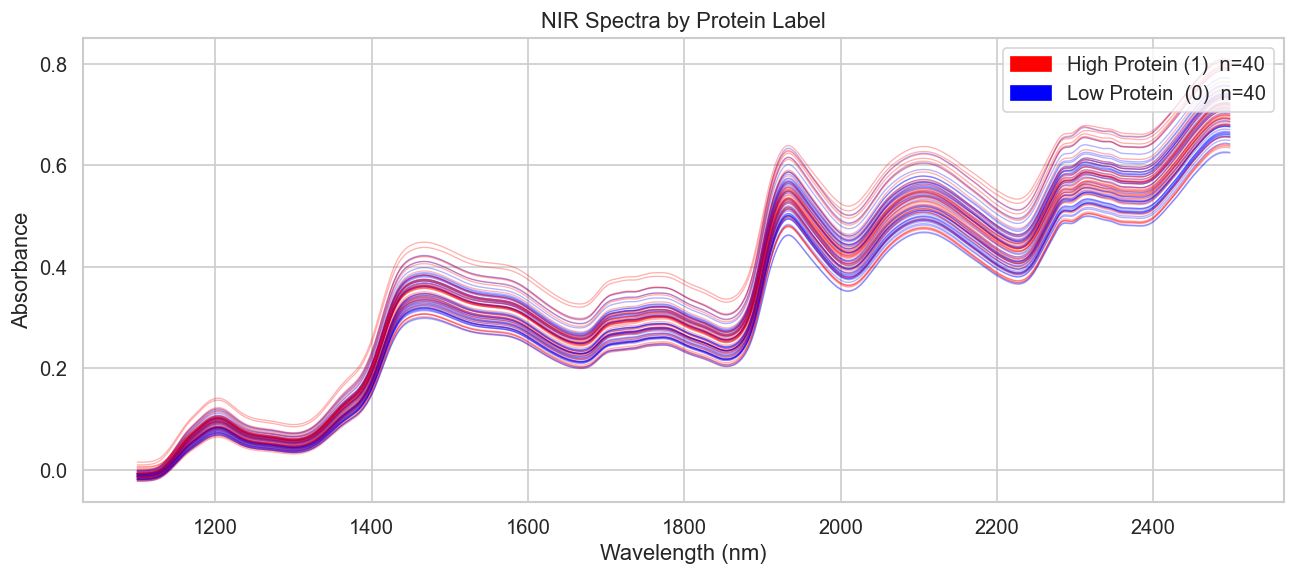

In [14]:
y = (labels_df['Protein'] >= median_protein).astype(int)
plot_spectra_by_label(X, y)

## Summary

Here is what we found from this initial exploration:

- **Dataset shape:** 80 samples × 701 columns (1 ID + 700 wavelengths + 4 labels)
- **Spectral features:** 700 wavelength channels covering 1100 nm to 2498 nm (step = 2 nm)
- **Label columns found:** Moisture, Starch, Oil, Protein
- **Protein range:** values are spread enough to support a meaningful binary split
- **Median protein value** was computed and will serve as the classification threshold in the next notebook
- **Spectral patterns:** The colored spectra plot (Section 6) shows some visible differences between High Protein and Low Protein groups, especially in certain wavelength regions — this suggests the NIR signal carries useful information for classification

**Next step:** `02_labeling.ipynb` — assign official binary class labels (High Protein = 1, Low Protein = 0) based on the median threshold found here.